In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd

data = {
    'email': [
        'Win free money now click here',
        'Hi how are you doing today',
        'Congratulations you won lottery',
        'Meeting tomorrow at 10am',
        'Free prize claim now urgent',
        'Can we discuss the project',
        'Buy cheap medicines online now',
        'Happy birthday have a great day',
        'Urgent your account needs verification',
        'Lets catch up for lunch tomorrow',
        'You have won 1 million dollars',
        'Please review the attached document',
        'Click here for free gifts now',
        'Thank you for your help today',
        'Limited offer buy now discount'
    ],
    'label': [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1]
}
# 1=Spam, 0=Not Spam

df = pd.DataFrame(data)
print(df)
print("\nSpam/Not Spam count:")
print(df['label'].value_counts())

                                     email  label
0            Win free money now click here      1
1               Hi how are you doing today      0
2          Congratulations you won lottery      1
3                 Meeting tomorrow at 10am      0
4              Free prize claim now urgent      1
5               Can we discuss the project      0
6           Buy cheap medicines online now      1
7          Happy birthday have a great day      0
8   Urgent your account needs verification      1
9         Lets catch up for lunch tomorrow      0
10          You have won 1 million dollars      1
11     Please review the attached document      0
12           Click here for free gifts now      1
13           Thank you for your help today      0
14          Limited offer buy now discount      1

Spam/Not Spam count:
label
1    8
0    7
Name: count, dtype: int64


In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Converts text to numbers
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['email'])
y = df['label']

# Splits the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)
acc = accuracy_score(y_test, predictions)
print("Accuracy:", acc)
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [4]:
#Test with new emails
new_emails = [
    "Win free cash prize now click here",
    "Hey can we meet for coffee tomorrow",
    "Congratulations you won free iPhone",
    "Please send me the report by evening"
]

# Convert to numbers
new_X = vectorizer.transform(new_emails)

# Predict
predictions = model.predict(new_X)

print("Email Predictions:")
print("-" * 40)
for email, pred in zip(new_emails, predictions):
    result = "🚨 SPAM" if pred == 1 else "✅ NOT SPAM"
    print(f"{result}: {email}")

Email Predictions:
----------------------------------------
🚨 SPAM: Win free cash prize now click here
✅ NOT SPAM: Hey can we meet for coffee tomorrow
🚨 SPAM: Congratulations you won free iPhone
✅ NOT SPAM: Please send me the report by evening


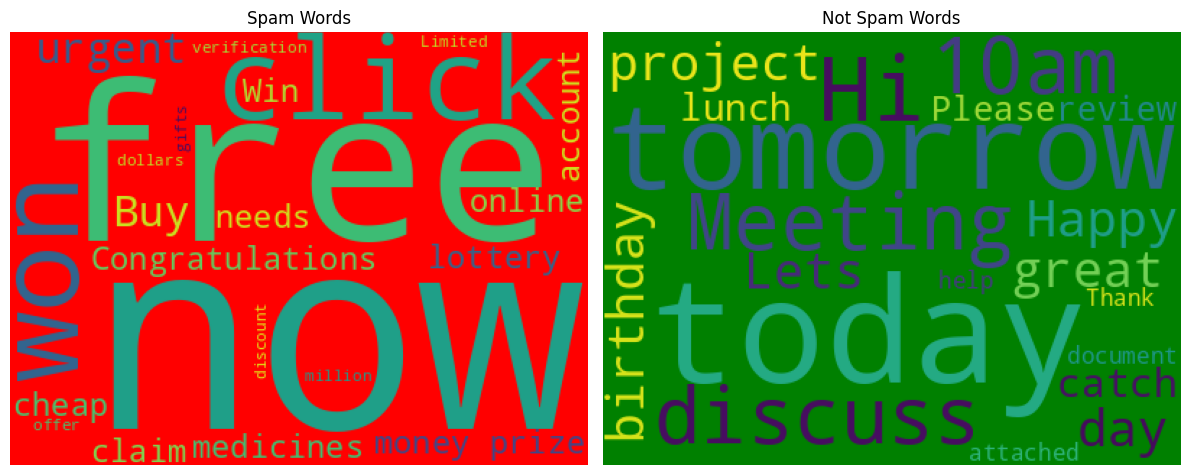

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Spam emails only
spam_emails = ' '.join(df[df['label']==1]['email'])
not_spam_emails = ' '.join(df[df['label']==0]['email'])

plt.figure(figsize=(12, 5))

# Spam word cloud
plt.subplot(1, 2, 1)
wc_spam = WordCloud(background_color='red', 
                    width=400, height=300).generate(spam_emails)
plt.imshow(wc_spam)
plt.title("Spam Words")
plt.axis('off')

# Not spam word cloud
plt.subplot(1, 2, 2)
wc_not = WordCloud(background_color='green',
                   width=400, height=300).generate(not_spam_emails)
plt.imshow(wc_not)
plt.title("Not Spam Words")
plt.axis('off')

plt.tight_layout()
plt.show()

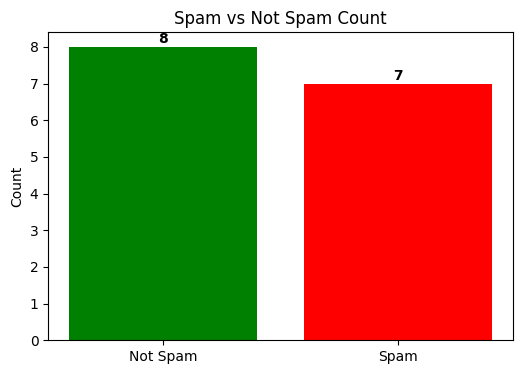

In [6]:
import matplotlib.pyplot as plt

# Count spam vs not spam
counts = df['label'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Not Spam', 'Spam'], counts.values, 
        color=['green', 'red'])
plt.title("Spam vs Not Spam Count")
plt.ylabel("Count")
for i, v in enumerate(counts.values):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.show()